In [10]:
from ultralytics import YOLO
model = YOLO("yolov8x.pt")
results = model("images.jpg")
results[0].show()



image 1/1 c:\Users\ASUS\Documents\Study\Major\images.jpg: 640x416 1 cup, 1 bowl, 1 dining table, 844.5ms
Speed: 2.2ms preprocess, 844.5ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 416)


In [13]:
!ls -R dataset


'ls' is not recognized as an internal or external command,
operable program or batch file.


In [17]:
from ultralytics.data.converter import convert_coco


convert_coco(
    labels_dir="train",
    save_dir="dataset_yolo_train",
    use_segments=False
)

Annotations C:\Users\ASUS\Documents\Study\Major\train\_annotations.coco.json: 0% ──────────── 4/3797 45.3it/s 0.0s<1:24


TypeError: must be real number, not NoneType

In [18]:
import json

with open("train/_annotations.coco.json") as f:
    data = json.load(f)

for ann in data["annotations"]:
    if ann["bbox"] is None:
        print("Found None bbox:", ann)
    elif any(v is None for v in ann["bbox"]):
        print("Found invalid bbox:", ann["bbox"])


In [19]:
import json

with open(r"C:\Users\ASUS\Documents\Study\Major\train\_annotations.coco.json") as f:
    data = json.load(f)

print("Total annotations:", len(data["annotations"]))


Total annotations: 5978


In [20]:
bad_annotations = []

for ann in data["annotations"]:
    bbox = ann.get("bbox", None)
    cat = ann.get("category_id", None)

    if (
        bbox is None or
        cat is None or
        len(bbox) != 4 or
        any(v is None for v in bbox) or
        bbox[2] <= 0 or
        bbox[3] <= 0
    ):
        bad_annotations.append(ann)

print("Bad annotations found:", len(bad_annotations))


Bad annotations found: 1


In [21]:
clean_annotations = []

for ann in data["annotations"]:
    bbox = ann.get("bbox", None)
    cat = ann.get("category_id", None)

    if (
        bbox is not None and
        cat is not None and
        len(bbox) == 4 and
        all(v is not None for v in bbox) and
        bbox[2] > 0 and
        bbox[3] > 0
    ):
        clean_annotations.append(ann)

data["annotations"] = clean_annotations

with open("clean_annotations.coco.json", "w") as f:
    json.dump(data, f)


In [28]:
zero_dim = []

for img in data["images"]:
    if img["width"] <= 0 or img["height"] <= 0:
        zero_dim.append(img)

print("Images with zero dimensions:", len(zero_dim))


Images with zero dimensions: 0


In [29]:
import json

with open("clean_annotations.coco.json") as f:
    data = json.load(f)

cat_ids = sorted({ann["category_id"] for ann in data["annotations"]})
print("Category IDs used:", cat_ids)


Category IDs used: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]


In [30]:
# Create remapping
old_ids = sorted([cat["id"] for cat in data["categories"]])
id_map = {old_id: new_id for new_id, old_id in enumerate(old_ids)}

# Update categories
for cat in data["categories"]:
    cat["id"] = id_map[cat["id"]]

# Update annotations
for ann in data["annotations"]:
    ann["category_id"] = id_map[ann["category_id"]]

with open("remapped_annotations.coco.json", "w") as f:
    json.dump(data, f)

print("Remapped IDs:", id_map)


Remapped IDs: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10, 11: 11, 12: 12, 13: 13, 14: 14, 15: 15, 16: 16, 17: 17, 18: 18, 19: 19, 20: 20, 21: 21, 22: 22, 23: 23, 24: 24, 25: 25, 26: 26, 27: 27, 28: 28, 29: 29, 30: 30}


In [1]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))


CUDA available: True
GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU


In [2]:
import os
print("Current working directory:")
print(os.getcwd())

print("\nDoes runs exist here?")
print(os.path.exists("runs"))


Current working directory:
c:\Users\ASUS\Documents\Study\Major

Does runs exist here?
False


In [32]:
import os
import glob
from collections import Counter

# Path to labels folder (train or val)
labels_path = r"Dataset\train\labels"   # change accordingly

label_files = glob.glob(os.path.join(labels_path, "*.txt"))

class_counts = Counter()

for file in label_files:
    with open(file, "r") as f:
        for line in f:
            class_id = int(line.split()[0])
            class_counts[class_id] += 1

# Map class IDs to names
for class_id, count in class_counts.items():
    print(f"{model.names[class_id]}: {count}")

WhiteRice: 199
Idli: 303
FishCurry: 157
Kulfi: 263
BhindiMasala: 157
Ghevar: 189
MuttonCurry: 146
OnionPakoda: 143
PalakPaneer: 161
Chole: 268
Chai: 203
Bhatura: 321
Dosa: 202
CoconutChutney: 207
Jalebi: 146
AlooMasala: 141
Biryani: 159
RajmaCurry: 140
Kebab: 358
Poha: 132
DumAloo: 153
GreenChutney: 197
ShahiPaneer: 142
Samosa: 242
Lassi: 213
GulabJamun: 422
AlooGobi: 132
RasMalai: 151
Dal: 152
Kheer: 179


In [33]:
sorted_counts = sorted(class_counts.items(), key=lambda x: x[1])

for class_id, count in sorted_counts:
    print(f"{model.names[class_id]}: {count}")

Poha: 132
AlooGobi: 132
RajmaCurry: 140
AlooMasala: 141
ShahiPaneer: 142
OnionPakoda: 143
MuttonCurry: 146
Jalebi: 146
RasMalai: 151
Dal: 152
DumAloo: 153
FishCurry: 157
BhindiMasala: 157
Biryani: 159
PalakPaneer: 161
Kheer: 179
Ghevar: 189
GreenChutney: 197
WhiteRice: 199
Dosa: 202
Chai: 203
CoconutChutney: 207
Lassi: 213
Samosa: 242
Kulfi: 263
Chole: 268
Idli: 303
Bhatura: 321
Kebab: 358
GulabJamun: 422


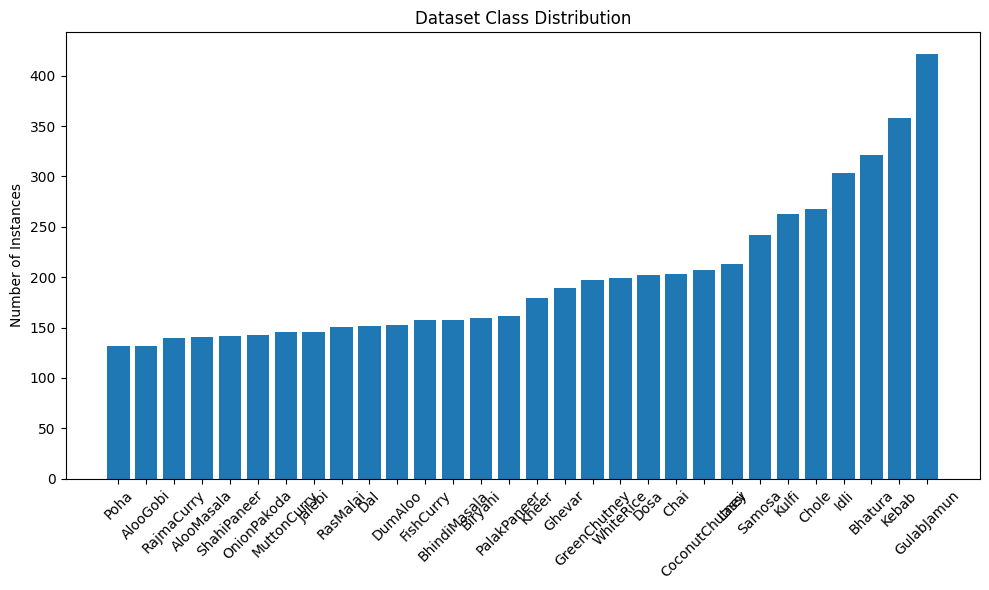

In [34]:
import matplotlib.pyplot as plt
import numpy as np

classes = []
counts = []

for class_id, count in sorted_counts:
    classes.append(model.names[class_id])
    counts.append(count)

plt.figure(figsize=(10,6))
plt.bar(classes, counts)
plt.xticks(rotation=45)
plt.ylabel("Number of Instances")
plt.title("Dataset Class Distribution")
plt.tight_layout()
plt.show()

In [3]:
import os
import glob

# 🔹 Update these paths
labels_path = r"\Dataset\train\labels"
images_path = r"\Dataset\train\images"

target_class_name = "Kebab"

# Get class ID for "kebab"
class_id = None
for k, v in model.names.items():
    if v == target_class_name:
        class_id = k
        break

if class_id is None:
    raise ValueError(f"Class '{target_class_name}' not found in model.names")

print(f"Class ID for '{target_class_name}': {class_id}")

label_files = glob.glob(os.path.join(labels_path, "*.txt"))

matched_images = []

for label_file in label_files:
    with open(label_file, "r") as f:
        lines = f.readlines()
        for line in lines:
            if int(line.split()[0]) == class_id:
                # Convert label path to image path
                image_file = os.path.basename(label_file).replace(".txt", ".jpg")
                image_full_path = os.path.join(images_path, image_file)

                matched_images.append(image_full_path)
                break  # Avoid duplicate count per image

    if len(matched_images) >= 50:
        break

print(f"\nFound {len(matched_images)} images containing '{target_class_name}':\n")

for img in matched_images:
    print(img)

Class ID for 'Kebab': 17

Found 0 images containing 'Kebab':



In [4]:
import os
import glob

labels_path = r"Dataset\train\labels"
images_path = r"Dataset\train\images"

target_class_id = 17   # since you confirmed this

label_files = glob.glob(os.path.join(labels_path, "*.txt"))

matched_images = []

for label_file in label_files:
    with open(label_file, "r") as f:
        lines = f.readlines()
        for line in lines:
            if int(line.split()[0]) == target_class_id:
                
                base_name = os.path.splitext(os.path.basename(label_file))[0]
                
                # Search for any matching image extension
                possible_images = glob.glob(os.path.join(images_path, base_name + ".*"))
                
                if possible_images:
                    matched_images.append(possible_images[0])
                
                break

    if len(matched_images) >= 50:
        break

print(f"\nFound {len(matched_images)} images containing class ID {target_class_id}:\n")

for img in matched_images:
    print(img)


Found 50 images containing class ID 17:

Dataset\train\images\0e831623c2c94cad86d7df9c217433eb_jpg.rf.346bc9c9463a23a9d32b0f00e1bc4905.jpg
Dataset\train\images\1200px-Pakistani_Food_Beef_Kabobs_jpg.rf.4ec706655b3834aa2e9f96d7226dad8b.jpg
Dataset\train\images\1630708008348_jpg.rf.8b8452833287293cfa95c1382296a86f.jpg
Dataset\train\images\20180925_180651_jpg.rf.d618bf32af55e2d88ee6cefd60230333.jpg
Dataset\train\images\20180925_180708_jpg.rf.96a5b226b6c49da9a3fcf90aaccc5787.jpg
Dataset\train\images\20180925_180823_jpg.rf.62df6c3af161f639f44742634a429f29.jpg
Dataset\train\images\20181008_170302_jpg.rf.1a7e4590d5a7d91b7bd8367c4f567249.jpg
Dataset\train\images\20181008_170359_jpg.rf.5abe2fda7d77a6dc71692ad5268b772e.jpg
Dataset\train\images\23-seekhkak_jpg.rf.9c4cca6c38c587f77318e637a50cf9f2.jpg
Dataset\train\images\63411b02a38858a6ec6dce303386397b_jpg.rf.c5df8a8e2b3103baa9c7ae1f8cc9d02d.jpg
Dataset\train\images\8145753-5f66429f57af4a62aade3adf71dc28d3_jpg.rf.5f8038587c8a6b39591baf4c0e4983e6.

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import math

# Number of images to display
num_images = len(matched_images)
cols = 5
rows = math.ceil(num_images / cols)

plt.figure(figsize=(15, 3 * rows))

for i, img_path in enumerate(matched_images):
    img = Image.open(img_path)

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.axis("off")
    # plt.title(os.path.basename(img_path), fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
from ultralytics import YOLO

# Load pretrained model (recommended)
model = YOLO("yolov8n.pt")   # nano model (fast, low VRAM)

# Train
model.train(
    data="data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    device=0   # GPU index (0 = first GPU)
)



New https://pypi.org/project/ultralytics/8.4.14 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.9  Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3070 Ti Laptop GPU, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs

In [1]:
import os

for root, dirs, files in os.walk(".", topdown=True):
    for name in files:
        if name.endswith(".pt") and ("best" in name or "last" in name):
            print(os.path.join(root, name))


In [7]:
boxes = result.boxes

print(boxes.xyxy)   # Bounding boxes in xyxy format
print(boxes.xywh)   # Bounding boxes in xywh format
print(boxes.conf)   # Confidence scores
print(boxes.cls)    # Class IDs


tensor([[1.0221e+01, 1.0036e+02, 1.4948e+02, 2.2263e+02],
        [1.3695e+00, 1.2815e+00, 1.8060e+02, 2.7768e+02],
        [9.2503e+01, 8.4905e-02, 1.8031e+02, 1.1261e+02]])
tensor([[ 79.8500, 161.4933, 139.2581, 122.2736],
        [ 90.9868, 139.4820, 179.2345, 276.4009],
        [136.4077,  56.3494,  87.8094, 112.5291]])
tensor([0.8833, 0.3950, 0.3469])
tensor([45., 60., 41.])


In [8]:
print(result.names)


{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microw

In [9]:
for box in boxes:
    class_id = int(box.cls)
    print(result.names[class_id], float(box.conf))


bowl 0.8833498954772949
dining table 0.3950076997280121
cup 0.34685301780700684


In [5]:
results

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p

In [ ]:
from ultralytics import YOLO

model = YOLO(r"C:\Users\ASUS\Documents\Study\ResumeForge\runs\detect\train2\weights\best.pt")

metrics = model.val(data="data.yaml")

print(metrics)


Ultralytics 8.4.9  Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3070 Ti Laptop GPU, 8192MiB)
Model summary (fused): 73 layers, 3,011,498 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.1 ms, read: 124.418.6 MB/s, size: 57.2 KB)
val: Scanning C:\Users\ASUS\Documents\Study\Major\valid\labels.cache... 1073 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1073/1073  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 68/68 2.2it/s 31.4s0.5ss
                   all       1073       1655      0.874      0.866       0.92      0.839
              AlooGobi         39         40      0.879        0.8        0.9      0.844
            AlooMasala         39         39      0.825      0.897      0.935      0.929
               Bhatura         44         87      0.868      0.903      0.944      0.809
          BhindiMasala         43         45      0.976      0.913      0.965      0.927
          

In [2]:
from ultralytics import YOLO

model = YOLO(r"C:\Users\ASUS\Documents\Study\ResumeForge\runs\detect\train2\weights\best.pt")

In [12]:
!ls

'ls' is not recognized as an internal or external command,
operable program or batch file.


In [14]:
metrics = model.val(data="data.yaml")

print(metrics)

Ultralytics 8.4.9  Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3070 Ti Laptop GPU, 8192MiB)
val: Fast image access  (ping: 0.20.1 ms, read: 101.460.5 MB/s, size: 98.7 KB)
val: Scanning C:\Users\ASUS\Documents\Study\Major\Project\Dataset\valid\labels... 1073 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1073/1073 620.7it/s 1.7s0.1s
val: New cache created: C:\Users\ASUS\Documents\Study\Major\Project\Dataset\valid\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 68/68 3.7it/s 18.5s0.2s
                   all       1073       1655      0.874      0.866       0.92      0.839
              AlooGobi         39         40      0.879        0.8        0.9      0.844
            AlooMasala         39         39      0.825      0.897      0.935      0.929
               Bhatura         44         87      0.868      0.903      0.944      0.809
          BhindiMasala         43         45      0.976      0

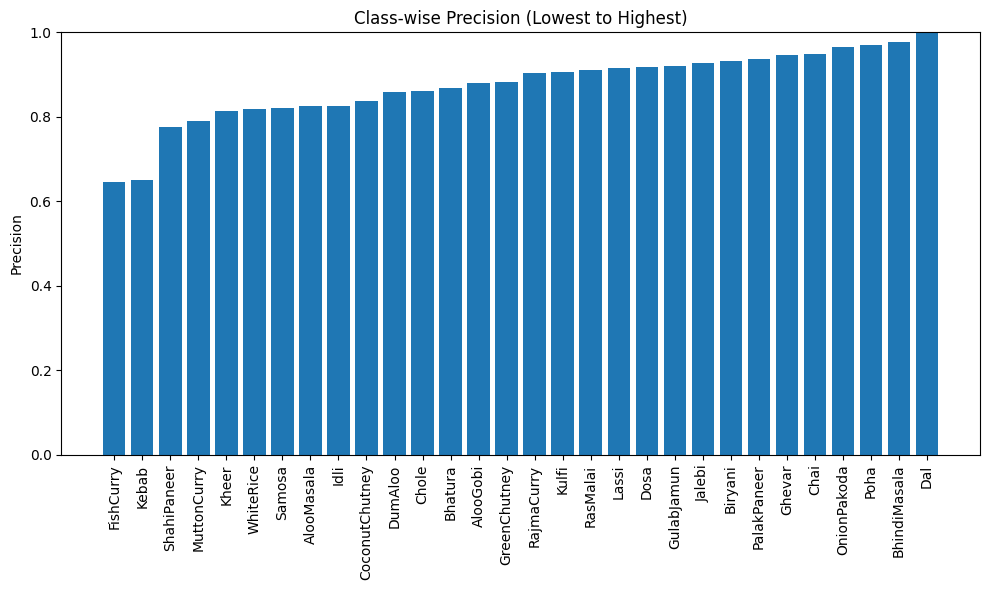

In [22]:
import numpy as np
import matplotlib.pyplot as plt

classes = []
precision = []

for i, cls_name in model.names.items():
    classes.append(cls_name)
    precision.append(metrics.box.p[i])

classes = np.array(classes)
precision = np.array(precision)

sorted_indices = np.argsort(precision)

classes_sorted = classes[sorted_indices]
precision_sorted = precision[sorted_indices]

plt.figure(figsize=(10, 6))
plt.bar(classes_sorted, precision_sorted)
plt.xticks(rotation=90)
plt.ylim(0, 1)
plt.ylabel("Precision")
plt.title("Class-wise Precision (Lowest to Highest)")
plt.tight_layout()
plt.show()

In [31]:
print(type(metrics))

<class 'ultralytics.utils.metrics.DetMetrics'>


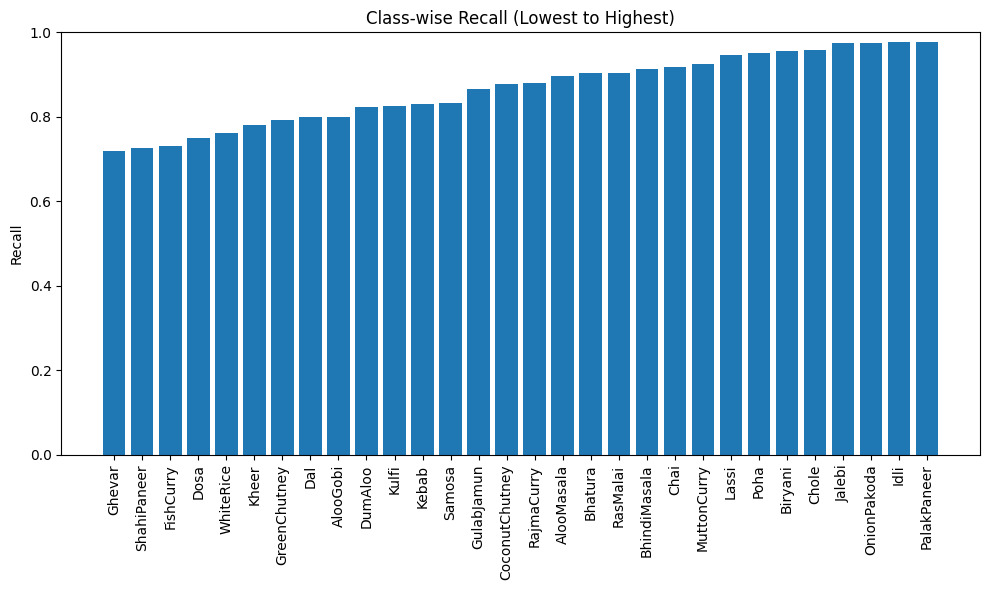

In [23]:
import numpy as np
import matplotlib.pyplot as plt

classes = []
recall = []

for i, cls_name in model.names.items():
    classes.append(cls_name)
    recall.append(metrics.box.r[i])

classes = np.array(classes)
recall = np.array(recall)

sorted_indices = np.argsort(recall)

classes_sorted = classes[sorted_indices]
recall_sorted = recall[sorted_indices]

plt.figure(figsize=(10, 6))
plt.bar(classes_sorted, recall_sorted)
plt.xticks(rotation=90)
plt.ylim(0, 1)
plt.ylabel("Recall")
plt.title("Class-wise Recall (Lowest to Highest)")
plt.tight_layout()
plt.show()

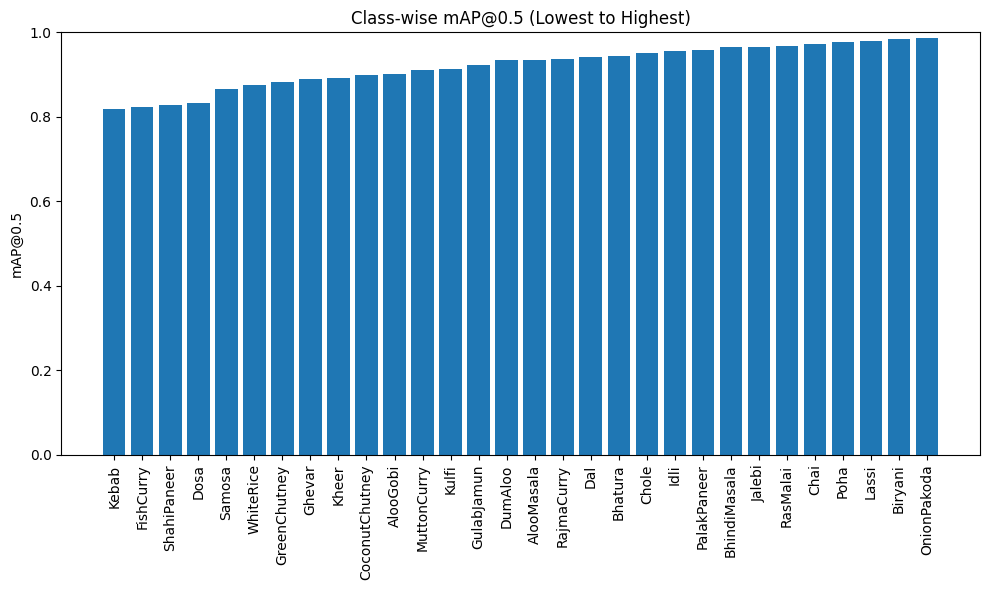

In [24]:
import numpy as np
import matplotlib.pyplot as plt

classes = []
map50 = []

for i, cls_name in model.names.items():
    classes.append(cls_name)
    map50.append(metrics.box.ap50[i])

classes = np.array(classes)
map50 = np.array(map50)

sorted_indices = np.argsort(map50)

classes_sorted = classes[sorted_indices]
map50_sorted = map50[sorted_indices]

plt.figure(figsize=(10, 6))
plt.bar(classes_sorted, map50_sorted)
plt.xticks(rotation=90)
plt.ylim(0, 1)
plt.ylabel("mAP@0.5")
plt.title("Class-wise mAP@0.5 (Lowest to Highest)")
plt.tight_layout()
plt.show()

In [9]:
import os
os.getcwd()

'c:\\Users\\ASUS\\Documents\\Study\\Major\\Project'

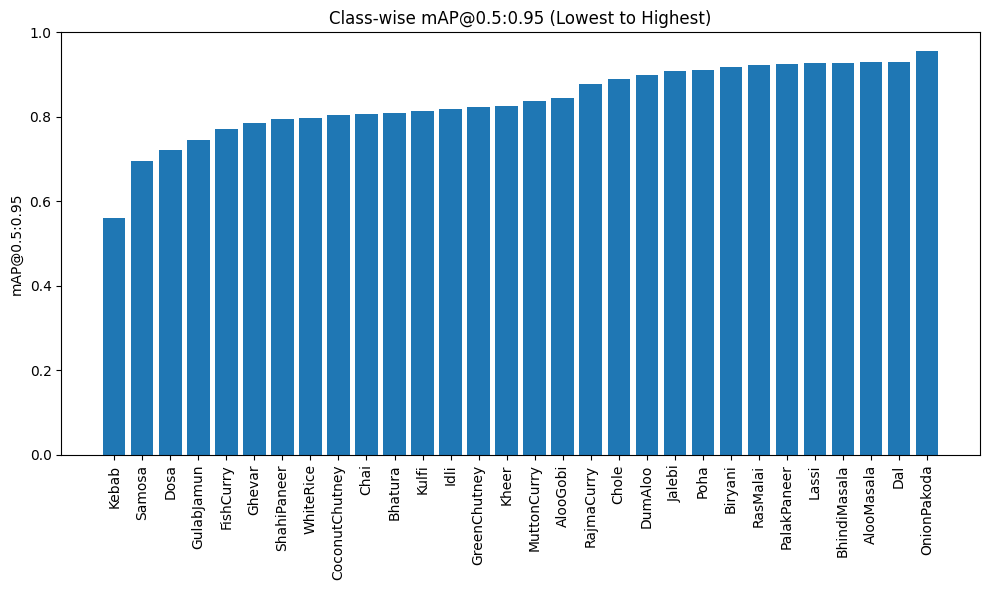

In [26]:
import numpy as np
import matplotlib.pyplot as plt

classes = []
map5095 = []

for i, cls_name in model.names.items():
    classes.append(cls_name)
    map5095.append(metrics.box.ap[i])

classes = np.array(classes)
map5095 = np.array(map5095)

sorted_indices = np.argsort(map5095)

classes_sorted = classes[sorted_indices]
map5095_sorted = map5095[sorted_indices]

plt.figure(figsize=(10, 6))
plt.bar(classes_sorted, map5095_sorted)
plt.xticks(rotation=90)
plt.ylim(0, 1)
plt.ylabel("mAP@0.5:0.95")
plt.title("Class-wise mAP@0.5:0.95 (Lowest to Highest)")
plt.tight_layout()
plt.show()

In [21]:
results = model.predict(
    source=r"images4.jpg",
    imgsz=640,
    conf=0.25,
    save=True,
    show=True
    
)

print(results)


image 1/1 c:\Users\ASUS\Documents\Study\Major\images4.jpg: 448x640 1 FishCurry, 25.5ms
Speed: 6.0ms preprocess, 25.5ms inference, 9.6ms postprocess per image at shape (1, 3, 448, 640)
Results saved to C:\Users\ASUS\Documents\Study\ResumeForge\runs\detect\predict3
[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'AlooGobi', 1: 'AlooMasala', 2: 'Bhatura', 3: 'BhindiMasala', 4: 'Biryani', 5: 'Chai', 6: 'Chole', 7: 'CoconutChutney', 8: 'Dal', 9: 'Dosa', 10: 'DumAloo', 11: 'FishCurry', 12: 'Ghevar', 13: 'GreenChutney', 14: 'GulabJamun', 15: 'Idli', 16: 'Jalebi', 17: 'Kebab', 18: 'Kheer', 19: 'Kulfi', 20: 'Lassi', 21: 'MuttonCurry', 22: 'OnionPakoda', 23: 'PalakPaneer', 24: 'Poha', 25: 'RajmaCurry', 26: 'RasMalai', 27: 'Samosa', 28: 'ShahiPaneer', 29: 'WhiteRice'}
obb: None
orig_img: array([[[  0,   0,  33],
        [  0,   0,  36],
        [  0,   0,  39],
        ...,
        [ 70,  45, 159],

In [18]:
from ultralytics import YOLO

model = YOLO(r"C:\Users\ASUS\Documents\Study\ResumeForge\runs\detect\train2\weights\best.pt")

model.predict(
    source="images4.jpg",
    show=True,
    save=False
)

input("Press Enter to exit...")



image 1/1 c:\Users\ASUS\Documents\Study\Major\images4.jpg: 448x640 1 FishCurry, 23.7ms
Speed: 8.3ms preprocess, 23.7ms inference, 8.0ms postprocess per image at shape (1, 3, 448, 640)


''

In [10]:
!ls C:\Users\ASUS\Documents\Study\ResumeForge\runs\detect\predict


'ls' is not recognized as an internal or external command,
operable program or batch file.


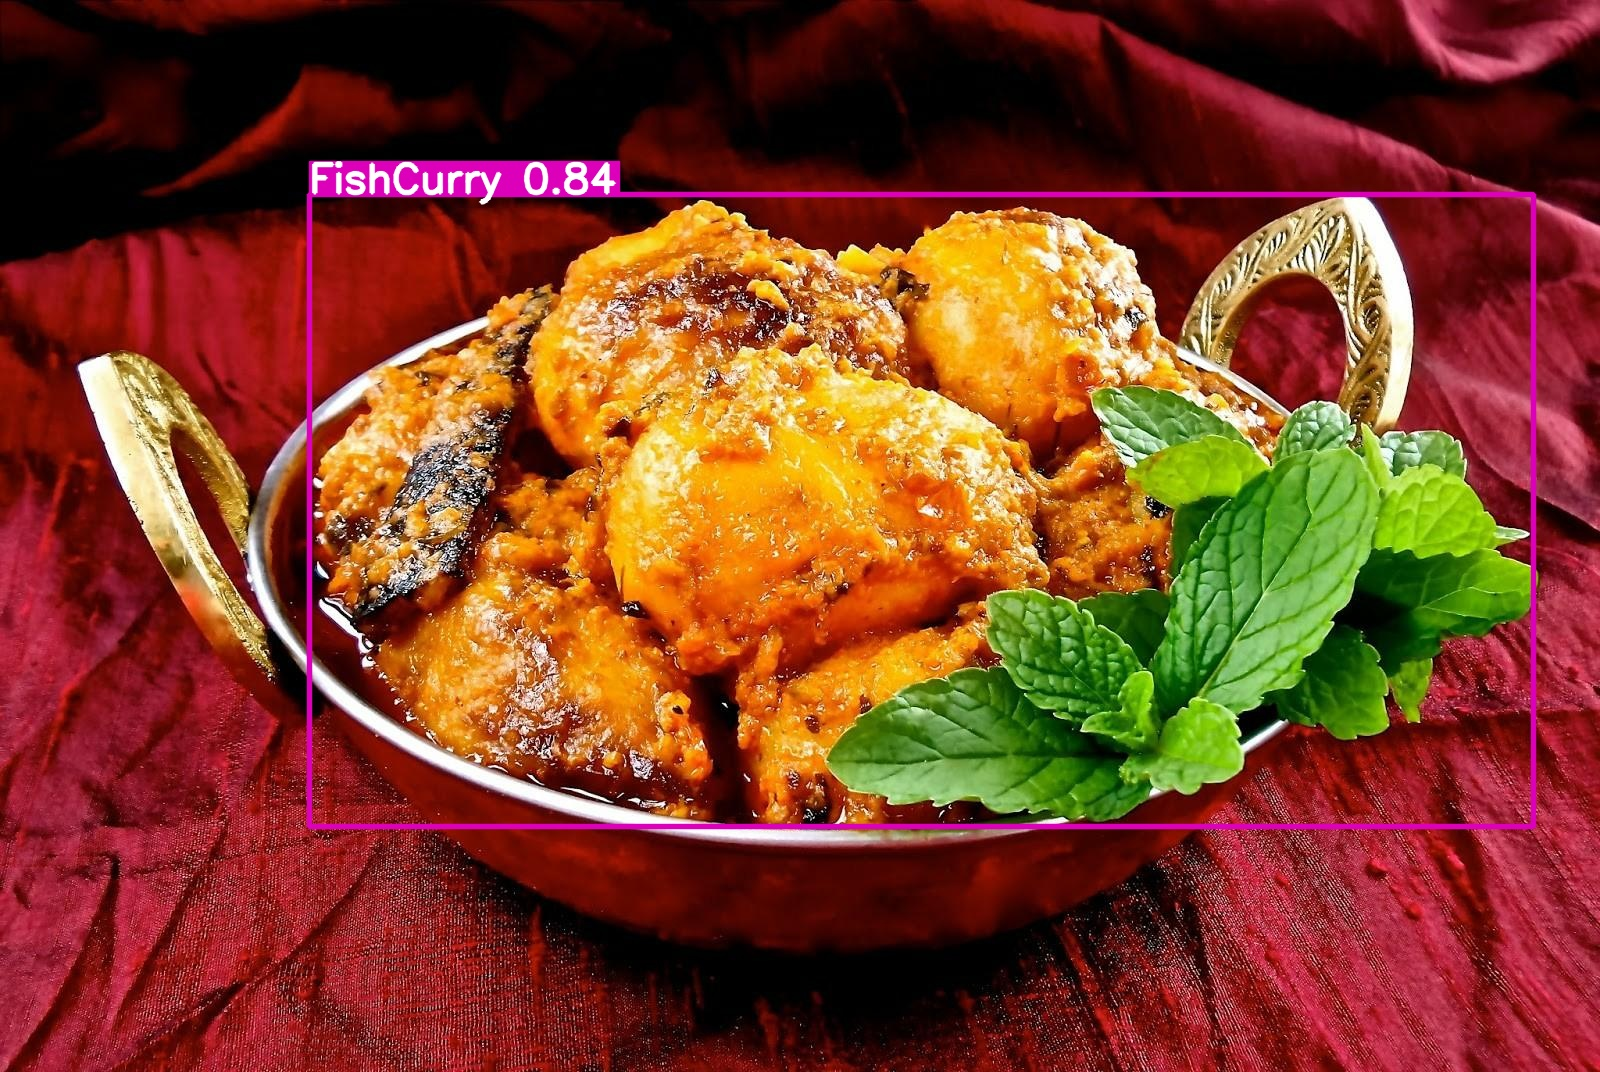

In [23]:
from IPython.display import Image
Image(r"C:\Users\ASUS\Documents\Study\ResumeForge\runs\detect\predict3\images4.jpg")



In [ ]:
from ultralytics import YOLO

model = YOLO(r"C:\Users\ASUS\Documents\Study\ResumeForge\runs\detect\train2\weights\best.pt")

model.predict(
    source=r"test/images",
    save=True,
    conf=0.25
)

print("Done. Check runs/detect/predict/")



image 1/576 c:\Users\ASUS\Documents\Study\Major\test\images\00e616b729045e474b8838f5d4a257e8_jpg.rf.84988e8a20088721bd21023d90772b86.jpg: 480x640 1 OnionPakoda, 134.7ms
image 2/576 c:\Users\ASUS\Documents\Study\Major\test\images\040420156316_jpg.rf.bb4d9d76c4e619bcbb595b02268d0bff.jpg: 416x640 1 Chole, 173.9ms
image 3/576 c:\Users\ASUS\Documents\Study\Major\test\images\0624c791ab263c6df98114119d6ed81e_jpg.rf.b28a738cddcb53c7aa417553ec47f553.jpg: 640x480 1 Bhatura, 1 RajmaCurry, 174.8ms
image 4/576 c:\Users\ASUS\Documents\Study\Major\test\images\08-recipe-of-How-To-Make-Rajasthani-Malai-Ghevar-by-anupama-paliwal_jpg.rf.c3788b49895f599620bfa5b50a1442ff.jpg: 640x512 1 Ghevar, 164.2ms
image 5/576 c:\Users\ASUS\Documents\Study\Major\test\images\08386d8f3adf24f14849cbfd376b7f89_jpg.rf.d076cadec855ae82b1a07c16715ad88b.jpg: 640x608 1 Jalebi, 162.0ms
image 6/576 c:\Users\ASUS\Documents\Study\Major\test\images\1-DSC02055_jpg.rf.3bc4b26f0924e27ff85a3ca780d21d96.jpg: 512x640 4 Idlis, 157.7ms
imag

In [1]:
import pandas as pd


In [2]:

df = pd.read_csv(r"C:\Users\ASUS\Documents\Study\ResumeForge\runs\detect\train2\results.csv")

In [3]:
df.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,224.168,0.73589,3.76678,1.25498,0.24843,0.35517,0.25175,0.20805,0.67333,2.33185,1.20433,0.000098,0.000098,0.000098
1,2,421.082,0.69118,2.51359,1.21073,0.43843,0.56101,0.51261,0.41579,0.69829,1.88682,1.21945,0.000194,0.000194,0.000194
2,3,610.011,0.66077,2.00267,1.18505,0.56521,0.60700,0.61754,0.50542,0.68656,1.54026,1.22630,0.000288,0.000288,0.000288
3,4,799.017,0.64727,1.72563,1.16973,0.59810,0.62818,0.65713,0.55389,0.62831,1.53644,1.17353,0.000285,0.000285,0.000285
4,5,983.807,0.62754,1.53823,1.15656,0.66790,0.68461,0.74058,0.63187,0.63499,1.23777,1.16664,0.000282,0.000282,0.000282


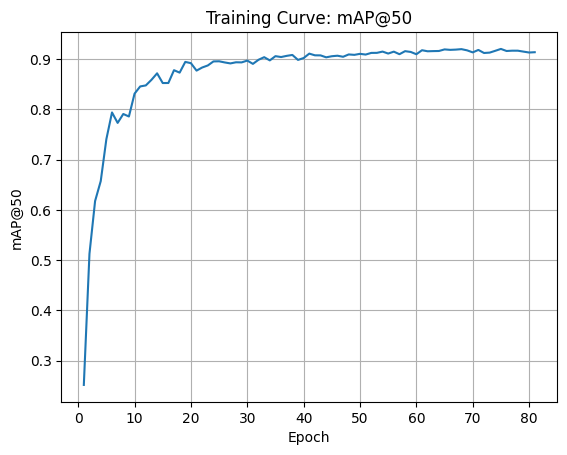

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df['epoch'], df['metrics/mAP50(B)'])
plt.xlabel('Epoch')
plt.ylabel('mAP@50')
plt.title('Training Curve: mAP@50')
plt.grid(True)
plt.show()

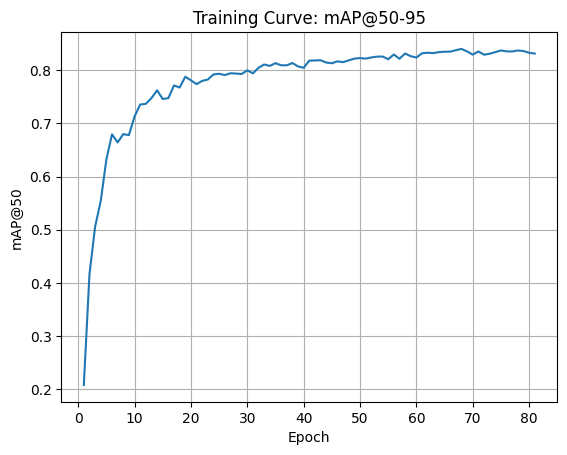

In [6]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df['epoch'], df['metrics/mAP50-95(B)'])
plt.xlabel('Epoch')
plt.ylabel('mAP@50')
plt.title('Training Curve: mAP@50-95')
plt.grid(True)
plt.show()

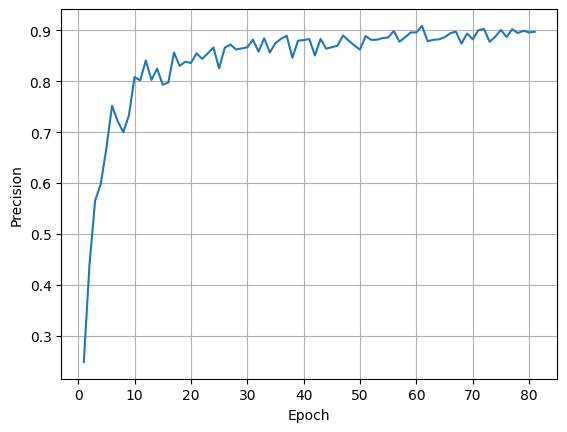

In [9]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(
    df['epoch'],
    df['metrics/precision(B)'],
      # shows each epoch as a point
)

plt.xlabel('Epoch')
plt.ylabel('Precision')
# plt.title('mAP@50 vs Epoch')
plt.grid(True)
plt.show()